In [1]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest

import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv("Train.csv")

print(data.shape)
print(data.head())

(10999, 12)
   ID Warehouse_block Mode_of_Shipment  Customer_care_calls  Customer_rating  \
0   1               D           Flight                    4                2   
1   2               F           Flight                    4                5   
2   3               A           Flight                    2                2   
3   4               B           Flight                    3                3   
4   5               C           Flight                    2                2   

   Cost_of_the_Product  Prior_purchases Product_importance Gender  \
0                  177                3                low      F   
1                  216                2                low      M   
2                  183                4                low      M   
3                  176                4             medium      M   
4                  184                3             medium      F   

   Discount_offered  Weight_in_gms  Reached.on.Time_Y.N  
0                44           1233

In [3]:
for col in data.select_dtypes(include=np.number):
    data[col].fillna(data[col].median(), inplace=True)

for col in data.select_dtypes(include='object'):
    data[col].fillna(data[col].mode()[0], inplace=True)

/tmp/ipykernel_199/3424158242.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[col].fillna(data[col].median(), inplace=True)
/tmp/ipykernel_199/3424158242.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

In [4]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in data.select_dtypes(include='object'):
    data[col] = le.fit_transform(data[col])

print("\nEncoded Data Sample:\n")
print(data.head())


Encoded Data Sample:

   ID  Warehouse_block  Mode_of_Shipment  Customer_care_calls  \
0   1                3                 0                    4   
1   2                4                 0                    4   
2   3                0                 0                    2   
3   4                1                 0                    3   
4   5                2                 0                    2   

   Customer_rating  Cost_of_the_Product  Prior_purchases  Product_importance  \
0                2                  177                3                   1   
1                5                  216                2                   1   
2                2                  183                4                   1   
3                3                  176                4                   2   
4                2                  184                3                   2   

   Gender  Discount_offered  Weight_in_gms  Reached.on.Time_Y.N  
0       0                44           1

In [6]:
X = data.copy()

print("\nFeatures Shape:", X.shape)


Features Shape: (10999, 12)


In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nData scaling completed!")


Data scaling completed!


In [9]:
model = IsolationForest(
    n_estimators=100,
    contamination=0.05,
    random_state=42
)

model.fit(X_scaled)

predictions = model.predict(X_scaled)

print("\nSample Predictions:\n", predictions[:10])


Sample Predictions:
 [ 1 -1 -1  1 -1  1  1 -1  1  1]


In [11]:
data['Anomaly'] = predictions

data['Anomaly'] = data['Anomaly'].map({1: 0, -1: 1})

print("\nAnomaly Count:\n")
print(data['Anomaly'].value_counts())


Anomaly Count:

Anomaly
0    10449
1      550
Name: count, dtype: int64


In [12]:
anomalies = data[data['Anomaly'] == 1]

print("\nDetected Anomalies:\n")
print(anomalies.head())


Detected Anomalies:

    ID  Warehouse_block  Mode_of_Shipment  Customer_care_calls  \
1    2                4                 0                    4   
2    3                0                 0                    2   
4    5                2                 0                    2   
7    8                4                 0                    4   
13  14                4                 0                    4   

    Customer_rating  Cost_of_the_Product  Prior_purchases  Product_importance  \
1                 5                  216                2                   1   
2                 2                  183                4                   1   
4                 2                  184                3                   2   
7                 1                  233                2                   1   
13                4                  275                3                   0   

    Gender  Discount_offered  Weight_in_gms  Reached.on.Time_Y.N  Anomaly  
1        1        

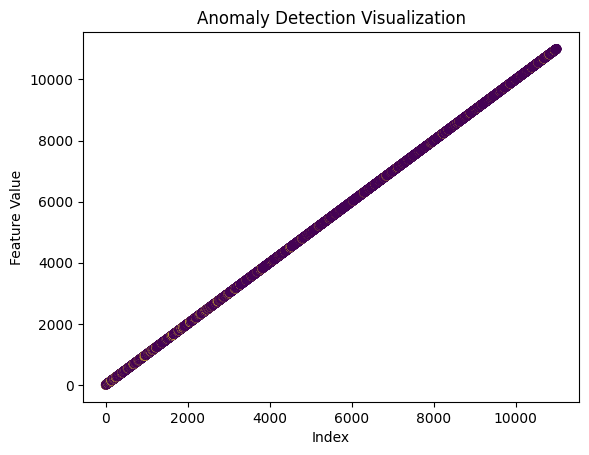

In [13]:
plt.figure()
plt.scatter(range(len(data)), data.iloc[:, 0], c=data['Anomaly'])
plt.title("Anomaly Detection Visualization")
plt.xlabel("Index")
plt.ylabel("Feature Value")
plt.show()